In [65]:
import sys
sys.path.append('../../src/fluprofiler/')
from tqdm import tqdm
import os
import torch
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from utilities import load_embedding, print_exams
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# 設置設備
device = torch.device('cuda:0')

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        # 生成嵌入文件名
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        # 轉換傳代類別為張量
        self.strainPassCats = convert_Pass2tensor(
            ('<cls>' + DataFrame['serumPassCat'] + '<eos>' + 
             DataFrame['virusPassCat'] + '<eos>').tolist()
        )
        
        # 標籤
        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (self.emb_file_name_a[idx], self.emb_file_name_b[idx], 
                self.emb_file_name_c[idx], self.emb_file_name_d[idx], 
                self.strainPassCats[idx], self.labels[idx])

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1')
             .replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    
    for i in range(len(matrix_list)): 
        # 填充矩陣到最大長度
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list), max_len)
    return matrix, mask

def list2df(mylist, period):
    merged_rows = []
    for i in range(0, len(mylist), period):
        merged_row = []
        for j in range(period):
            merged_row += mylist[i + j]
        merged_rows.append(merged_row)
    return pd.DataFrame(merged_rows)

In [122]:
def cluster_virus(df, vector, drop_duplicate=False):

    if drop_duplicate:
        df_arr = pd.DataFrame(vector, columns=[f'col_{i}' for i in range(vector.shape[1])])
        df_merged = pd.concat([df.reset_index(drop=True), df_arr], axis=1)
        df_merged["virusDate"] = pd.to_datetime(df_merged["virusDate"], errors="coerce")
        
        aggregate_dict = {col: 'first' for col in df_merged.columns if col != 'seq_c'}
        aggregate_dict['virusDate'] = 'min'
        df_agg = df_merged.groupby('seq_c').agg(aggregate_dict).reset_index()
        df = df_agg.iloc[:, :-2560]
        vector = np.array(df_agg.iloc[:, -2560:])

    # elbow_method(vector)
    
    pca_2d = PCA(n_components=2, random_state=42)
    X_2d = pca_2d.fit_transform(vector)

    k = 2
    labels = KMeans(n_clusters=k, random_state=441).fit_predict(X_2d)
    
    df_plot = pd.DataFrame(X_2d, columns=['x', 'y'])
    df_plot['cluster'] = labels.astype(str)
    df_plot['type'] = df['Type'].tolist()
    df_plot['virusDate'] = df['virusDate']
    df_plot['virusIslID'] = df['virusIslID'].tolist()

    return df_plot

def plot_virus_scatter(df_plot, color_map=None, save_path=None):
    plt.figure(figsize=(5, 3.5))

    order = ['Crick', 'CDC', 'CNIC']  # 你想要的顺序

    for t in order:
        subdf = df_plot[df_plot['type'] == t]  # 筛选对应类型的数据
        if len(subdf) == 0:
            continue  # 防止某类不存在时报错

        plt.scatter(subdf["x"], subdf["y"],
                    label=t,
                    c=color_map.get(t, "gray"),
                    s=8, alpha=0.45, lw=0)

    # ===== 样式 =====
    plt.xlabel("component-1", fontsize=14)
    plt.ylabel("component-2", fontsize=14)
    
    plt.legend(frameon=False, fontsize=10, loc='upper left', bbox_to_anchor=(0.98, 1), 
    markerscale=2, alignment='left')

    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    if save_path is not None:
        ext = os.path.splitext(save_path)[1].lower()

        if ext == '.png':
            plt.savefig(save_path, dpi=600, transparent=True,
                        pil_kwargs={"compress_level": 0}, bbox_inches="tight")
        elif ext == '.svg':
            plt.savefig(save_path, format='svg', bbox_inches="tight")
    else:
        plt.show()

def plot_virus_scatter_time(df_plot, save_path=None):
    """
    根据virusDate由浅到深绘制散点（自然色渐变：蓝→绿→黄）。
    """
    fig, ax = plt.subplots(figsize=(7, 3.5))

    # 确保时间格式并去掉NaT
    df_plot = df_plot.copy()
    df_plot["virusDate"] = pd.to_datetime(df_plot["virusDate"], errors="coerce")
    df_plot = df_plot.dropna(subset=["virusDate"])
    if df_plot.empty:
        raise ValueError("virusDate 列全部为空或无法解析为日期")

    # 按时间排序（保证后期点覆盖早期点）
    df_plot = df_plot.sort_values("virusDate")

    # 时间归一化（排除极端值，避免色带压缩）
    vmin = df_plot["virusDate"].quantile(0.05).timestamp()
    vmax = df_plot["virusDate"].quantile(0.95).timestamp()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # 自然色 colormap
    cmap = plt.get_cmap("cividis")

    # 绘制散点
    sc = ax.scatter(df_plot["x"], df_plot["y"],
                    c=df_plot["virusDate"].apply(lambda x: x.timestamp()),
                    cmap=cmap, norm=norm,
                    s=6, alpha=0.6, lw=0)

    # 颜色条
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
    ticks = np.linspace(vmin, vmax, 6)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(pd.to_datetime(ticks, unit="s").strftime("%Y"))  # 只显示年份
    cbar.set_label("Isolation year", fontsize=10)

    # 样式
    ax.set_xlabel("PC1", fontsize=10)
    ax.set_ylabel("PC2", fontsize=10)
    # ax.grid(True, linestyle="--", alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_aspect('equal')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, transparent=True,
                    bbox_inches="tight", pil_kwargs={"compress_level": 0})
    else:
        plt.show()

def plot_virus_scatter_time_nature(df_plot, save_path=None, title=None):
    """
    Nature-style scatter by virusDate.

    Parameters
    ----------
    df_plot : pd.DataFrame
        必须包含 ['x', 'y', 'virusDate'] 三列。
    save_path : str or None
        输出路径，支持 .png/.svg。None 时直接显示。
    title : str or None
        可选标题。
    """
    required_cols = {"x", "y", "virusDate"}
    missing = required_cols - set(df_plot.columns)
    if missing:
        raise ValueError(f"缺少必要列: {sorted(missing)}")

    # 复制并清洗日期
    d = df_plot.copy()
    d["virusDate"] = pd.to_datetime(d["virusDate"], errors="coerce")
    d = d.dropna(subset=["virusDate", "x", "y"]).sort_values("virusDate")
    if d.empty:
        raise ValueError("有效数据为空：请检查 virusDate/x/y 是否可解析")

    # 局部风格设置，避免污染全局 rcParams
    with plt.style.context("default"):
        plt.rcParams.update({
            "font.family": "DejaVu Sans",
            "font.size": 9,
            "axes.labelsize": 10,
            "xtick.labelsize": 8.5,
            "ytick.labelsize": 8.5,
        })

        fig, ax = plt.subplots(figsize=(5.1, 3.6), dpi=260)

        # 用分位数压掉极端年份，色带更均衡
        t = d["virusDate"].map(pd.Timestamp.timestamp).to_numpy()
        vmin, vmax = np.quantile(t, [0.03, 0.97])
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap("cividis")

        ax.scatter(
            d["x"],
            d["y"],
            c=t,
            cmap=cmap,
            norm=norm,
            s=15,
            alpha=0.86,
            linewidths=0.22,
            edgecolors="white",
            rasterized=True,
            zorder=2,
        )

        # 轻网格 + 干净坐标轴
        ax.grid(True, linestyle="-", linewidth=0.45, alpha=0.16, color="#8a8a8a")
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)
        ax.tick_params(direction="out", width=0.8, length=3)

        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        if title:
            ax.set_title(title, pad=5)

        # 窄 colorbar（更像期刊图）
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, shrink=0.92)
        ticks = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels(pd.to_datetime(ticks, unit="s").strftime("%Y"))
        cbar.set_label("Collection year", fontsize=8.8)
        cbar.ax.tick_params(labelsize=8)
        cbar.outline.set_linewidth(0.6)

        plt.tight_layout(pad=0.6)

        if save_path:
            ext = os.path.splitext(save_path)[1].lower()
            if ext == ".svg":
                plt.savefig(save_path, format="svg", bbox_inches="tight", transparent=True)
            else:
                plt.savefig(
                    save_path,
                    dpi=600,
                    bbox_inches="tight",
                    transparent=True,
                    pil_kwargs={"compress_level": 0},
                )
        else:
            plt.show()


## 数据加载

In [2]:
All_data = pd.read_csv('../../data/reverse_test/processed/All.csv')

In [3]:
# load embedding
Crick_df = All_data[(All_data['seq_a'].str.len() >= 566) & (All_data['seq_c'].str.len() >= 566)]
sequence_names = pd.concat([Crick_df['seq_id_a'], Crick_df['seq_id_c']]).unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
emb_dict_Crick = load_embedding("../../data/reverse_test/embedding/", files=sequence_names)

Loading tensor: 100%|██████████| 6868/6868 [04:30<00:00, 25.34file/s]


In [ ]:
Crick_vector = np.stack([np.asarray(emb_dict_Crick['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in Crick_df['seq_id_c']])

## 病毒进化可视化

#### 病毒

In [112]:
# Crick_df.to_csv('Evolution_data.csv', index=False)
# np.save("Evolution_vectors.npy", Crick_vector)
Crick_df = pd.read_csv('Evolution_data.csv')
Crick_vector = np.load('Evolution_vectors.npy')

In [113]:
plot_df = cluster_virus(Crick_df, Crick_vector, drop_duplicate=True)

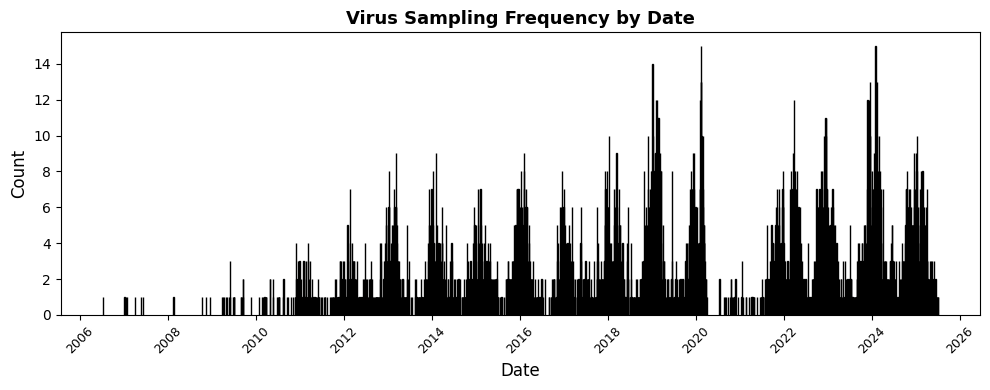

In [ ]:
# 假设你的时间列表叫 time_list
time_series = plot_df.loc[:, 'virusDate']
time_series = pd.to_datetime(time_series)

# 按日期统计频率
freq = time_series.value_counts().sort_index()

# 绘制按天的频率直方图
plt.figure(figsize=(10, 4))
plt.bar(freq.index, freq.values, width=1.0, color="#71B7ED", edgecolor="black")

plt.xlabel("Date", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Virus Sampling Frequency by Date", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, fontsize=9)
plt.tight_layout()
plt.show()

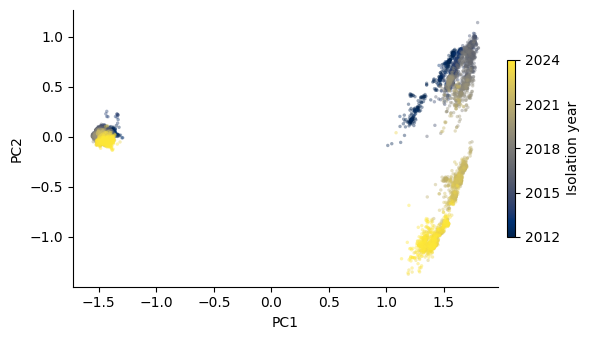

In [187]:
plot_df_filt = plot_df
plot_virus_scatter_time(plot_df_filt, add_centroid=False)

In [217]:
def plot_virus_scatter_time(df_plot, save_path=None, add_centroid=True, label_centroid=True, color_quantile=(0.05, 0.95)):
    """
    根据 virusDate 由浅到深绘制散点，并可叠加按年份的 centroid 层。
    """
    fig, ax = plt.subplots(figsize=(6, 3.5))

    # 确保时间格式并去掉 NaT
    df_plot = df_plot.copy()
    df_plot["virusDate"] = pd.to_datetime(df_plot["virusDate"], errors="coerce")
    df_plot = df_plot.dropna(subset=["virusDate"])
    if df_plot.empty:
        raise ValueError("virusDate 列全部为空或无法解析为日期")

    # 按时间排序（保证后期点覆盖早期点）
    df_plot = df_plot.sort_values("virusDate")

    # 时间归一化（排除极端值，避免色带压缩）
    vmin = df_plot["virusDate"].quantile(color_quantile[0]).timestamp()
    vmax = df_plot["virusDate"].quantile(color_quantile[1]).timestamp()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # colormap
    cmap = plt.get_cmap("cividis")

    # 主散点
    ax.scatter(
        df_plot["x"], df_plot["y"],
        c=df_plot["virusDate"].apply(lambda x: x.timestamp()),
        cmap=cmap, norm=norm,
        s=6, alpha=0.4, lw=0, zorder=1
    )

    # 年份 centroid 层
    if add_centroid:
        df_plot["year"] = df_plot["virusDate"].dt.year

        year_centroids = (
            df_plot.groupby("year", as_index=False)
            .agg(
                x_centroid=("x", "mean"),
                y_centroid=("y", "mean"),
                n=("x", "size")
            )
            .sort_values("year")
        )

        # 可选：去掉样本太少的年份，避免轨迹受离群年份影响
        # year_centroids = year_centroids[year_centroids["n"] >= 5].copy()

        # 用每年中点日期来映射颜色
        year_centroids["year_date"] = pd.to_datetime(year_centroids["year"].astype(str) + "-07-01")
        year_centroids["year_ts"] = year_centroids["year_date"].apply(lambda x: x.timestamp())

        # 连接线
        ax.plot(
            year_centroids["x_centroid"],
            year_centroids["y_centroid"],
            color="0.35",
            lw=1.5,
            alpha=0.8,
            zorder=3
        )

        # centroid 点
        ax.scatter(
            year_centroids["x_centroid"],
            year_centroids["y_centroid"],
            c=year_centroids["year_ts"],
            cmap=cmap,
            norm=norm,
            s=22,
            edgecolor="black",
            linewidth=0.9,
            zorder=4
        )

        # 是否标年份
        if label_centroid:
            for _, row in year_centroids.iterrows():
                ax.text(
                    row["x_centroid"] + 0.002,
                    row["y_centroid"] + 0.002,
                    str(int(row["year"])),
                    fontsize=10,
                    color="0.25",
                    zorder=5
                )

    # 颜色条
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
    ticks = np.linspace(vmin, vmax, 5)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(pd.to_datetime(ticks, unit="s").strftime("%Y"))
    cbar.set_label("Isolation year", fontsize=10)

    # 样式
    ax.set_xlabel("PC1", fontsize=10)
    ax.set_ylabel("PC2", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(labelsize=8, length=3)

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=600,
            transparent=True,
            bbox_inches="tight",
            pil_kwargs={"compress_level": 0}
        )
    else:
        plt.show()

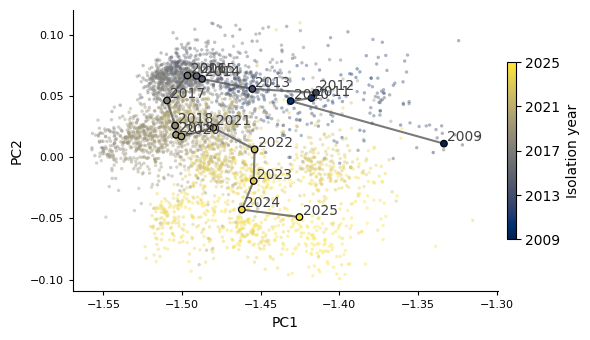

In [218]:
plot_df_filt = plot_df[plot_df['type'].isin(['H1N1', 'H1N1_2024NH', 'H1N1_2024SH', 'H1N1_2025NH'])]
# plot_df_filt = plot_df_filt[plot_df_filt['virusDate'] >= '2010-08-31']
plot_df_filt = plot_df_filt[plot_df_filt['x'] < -1.3]
plot_df_filt = plot_df_filt[(plot_df_filt['y'] < 0.11) & (plot_df_filt['y'] > -0.1)]
# plot_virus_scatter_time(plot_df_filt, color_quantile=(0, 1), label_centroid=False, save_path='H1N1_evo.png')
plot_virus_scatter_time(plot_df_filt, color_quantile=(0, 1))

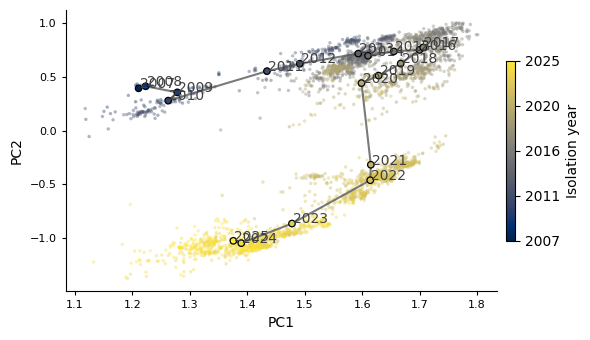

In [219]:
plot_df_filt = plot_df[plot_df['type'].isin(['H3N2', 'H3N2_2024NH', 'H3N2_2024SH', 'H3N2_2025NH'])]
plot_df_filt = plot_df_filt[plot_df_filt['x'] > 1.1]
plot_df_filt = plot_df_filt[plot_df_filt['y'] < 1]
# plot_virus_scatter_time(plot_df_filt, color_quantile=(0, 1), label_centroid=False, save_path='H3N2_evo.png')
plot_virus_scatter_time(plot_df_filt, color_quantile=(0, 1))

#### 血清

In [61]:
Crick_df = Crick_early.copy()
Crick_df = Crick_df[Crick_df['seq_a'].str.len() == 566].drop_duplicates(subset=['seq_a']).reset_index(drop=True)

In [62]:
df_41 = Crick_41.copy()
df_41 = df_41.loc[(df_41['seq_a'].str.len() == 566),:].drop_duplicates(subset=['seq_a']).reset_index(drop=True)
df_41['Type'] = df_41['Type'] + '_2024NH'
df_42 = Crick_42.copy()
df_42 = df_42.loc[(df_42['seq_a'].str.len() == 566),:].drop_duplicates(subset=['seq_a']).reset_index(drop=True)
df_42['Type'] = df_42['Type'] + '_2024SH'
df_43 = Crick_43.copy()
df_43 = df_43.loc[(df_43['seq_a'].str.len() == 566),:].drop_duplicates(subset=['seq_a']).reset_index(drop=True)
df_43['Type'] = df_43['Type'] + '_2025NH'

all_df = pd.concat([Crick_df, df_41, df_42, df_43]).reset_index(drop=True)

In [ ]:
# load embedding
sequence_names = Crick_early['seq_id_a'].unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
Crick_early_serum_emb = load_embedding("../../data/data_40/embedding_Crick", files=sequence_names)

Loading tensor: 100%|██████████| 197/197 [00:26<00:00,  7.32file/s]


In [ ]:
sequence_names = df_41['seq_id_a'].unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
Crick_41_serum_emb = load_embedding("../../data/data_40/embedding_41", files=sequence_names)

Loading tensor: 100%|██████████| 14/14 [00:02<00:00,  5.81file/s]


In [ ]:
sequence_names = df_42['seq_id_a'].unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
Crick_42_serum_emb = load_embedding("../../data/data_40/embedding_42", files=sequence_names)

Loading tensor: 100%|██████████| 22/22 [00:01<00:00, 13.82file/s]


In [ ]:
sequence_names = df_43['seq_id_a'].unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
Crick_43_serum_emb = load_embedding("../../data/data_40/embedding_43", files=sequence_names)

Loading tensor: 100%|██████████| 16/16 [00:02<00:00,  6.04file/s]


In [66]:
vector_Crick_early = np.stack([np.asarray(Crick_early_serum_emb['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in Crick_df['seq_id_a']])
vector_41 = np.stack([np.asarray(Crick_41_serum_emb['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_41['seq_id_a']])
vector_42 = np.stack([np.asarray(Crick_42_serum_emb['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_42['seq_id_a']])
vector_43 = np.stack([np.asarray(Crick_43_serum_emb['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_43['seq_id_a']])
all_vector = np.vstack([vector_Crick_early, vector_41, vector_42, vector_43])

In [67]:
all_vector.shape 

(232, 2560)

In [68]:
color_map = {
        'H1N1': 'red',
        'H3N2': 'blue',
        'H1N1_2024NH': 'cyan',
        'H3N2_2024NH': 'cyan',
        'H1N1_2024SH': 'magenta',
        'H3N2_2024SH': 'magenta',
        'H1N1_2025NH': 'orange',
        'H3N2_2025NH': 'orange'
    }

plot_df = cluster_virus(all_df, all_vector)

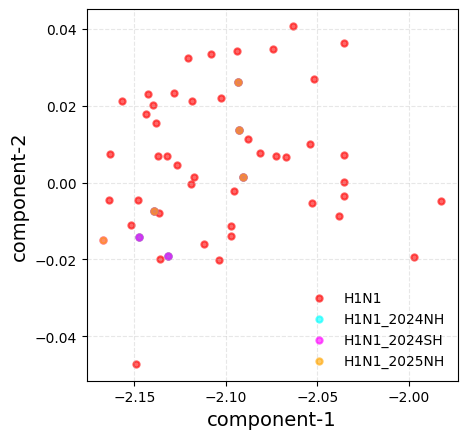

In [69]:
plot_virus_scatter(plot_df[plot_df['type'].isin(['H1N1', 'H1N1_2024NH', 'H1N1_2024SH', 'H1N1_2025NH'])], color_map, save_path='H1N1_evo.png')

In [ ]:
# 将重复的数据加载 + 聚合逻辑封装，避免后续多段重复代码

def build_cdc_test_df(csv_path='../../data/data_40/CDC_all.csv', cutoff_date='2023-08-31'):
    cdc_data = pd.read_csv(csv_path)
    cdc_data['seq_diff_ohe'] = cdc_data['seq_diff_ohe'].apply(ast.literal_eval)
    cdc_data = cdc_data.loc[cdc_data['virusDate'] <= cutoff_date, :]

    group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
    agg_dict = {c: 'first' for c in cdc_data.columns if c not in group_columns}
    agg_dict['label'] = 'mean'
    return cdc_data.groupby(group_columns).agg(agg_dict).reset_index()


def predict_adaboost_pair(df, meta_features, with_name=True):
    if with_name:
        work_df = df
        model_files = {
            'H1N1': 'Adaboost_H1N1_titer.pkl',
            'H3N2': 'Adaboost_H3N2_titer.pkl',
        }
        target_col = 'pred_with_name'
    else:
        work_df = df.copy()
        work_df.loc[:, 'serumName'] = ''
        work_df.loc[:, 'virusName'] = ''
        model_files = {
            'H1N1': 'Adaboost_H1N1_serum.pkl',
            'H3N2': 'Adaboost_H3N2_serum.pkl',
        }
        target_col = 'pred_without_name'

    for virus_type, model_file in model_files.items():
        _, prediction = predict_Adaboost_titer(
            work_df[work_df['Type'] == virus_type],
            meta_features,
            model_file,
        )
        df.loc[df['Type'] == virus_type, target_col] = prediction

    return target_col


test_df = build_cdc_test_df()

In [ ]:
pred_col = predict_adaboost_pair(test_df, meta_features, with_name=True)
result = print_exams(test_df[pred_col], test_df['label'])

MAE: 1.06258
MSE: 2.10216
pearson correlation: 0.75137
spearman correlation: 0.70609
R2_score: 0.50620


In [ ]:
pred_col = predict_adaboost_pair(test_df, meta_features, with_name=False)
result = print_exams(test_df[pred_col], test_df['label'])

MAE: 1.07081
MSE: 2.16056
pearson correlation: 0.74549
spearman correlation: 0.69442
R2_score: 0.49248


In [ ]:
test_df.to_csv('../../Figure/Fig2/Adaboost_CDC.csv', index=False)

In [88]:
import plotly.express as px
import pandas as pd


df = pd.DataFrame(X_3d, columns=['x', 'y', 'z'])
df['cluster'] = labels.astype(str)
df['type'] = all_df['Type'].tolist()
df['virusDate'] = all_df['virusDate'].tolist()
df['virusIslID'] = all_df['virusIslID'].tolist()
# 1. 确保 type 只有两类
# assert df['type'].nunique() == 4, 'type 必须是恰好两类'

# 2. 手动指定颜色：红 & 蓝
# color_map = {'H1N1': 'red',   # 把 'class_A' 换成你实际的第一类名称
#              'H3N2': 'blue',
#              '43': 'yellow'}  # 把 'class_B' 换成第二类名称
# color_map = {'H1N1': 'red',   # 把 'class_A' 换成你实际的第一类名称
#              'H3N2': 'blue',
        #      'H1N1_CDC': 'yellow',
        #      'H3N2_CDC': 'green',
        #      'H1N1_43': 'rgba(125,125,125,10)',
        #      'H3N2_43': 'rgba(255,255,0,1)'}  # 把 'class_B' 换成第二类名称
color_map = {
    'H1N1': 'rgba(220,  20,  60, 1)',   # 鲜红（实色）
    'H3N2': 'rgba(220,  20,  60, 1)',   # 深蓝（实色）

    # 'H1N1_CDC': 'rgba(  0,  90, 181, 0.1)',
    # 'H3N2_CDC': 'rgba(  0,  90, 181, 0.1)',

    # 'H1N1_CNIC': 'rgba(255, 255, 0, 0.10)',
    # 'H3N2_CNIC': 'rgba(255, 255, 0, 0.10)',

    'H1N1_2024NH': 'rgba(  0, 255, 255, 0.10)', # 霓虹青 10 % 不透明
    'H3N2_2024NH': 'rgba(  0, 255, 255, 0.10)',

    'H1N1_2024SH': 'rgba(255,   0, 255, 0.10)', # 霓虹紫 10 % 不透明
    'H3N2_2024SH': 'rgba(255,   0, 255, 0.10)',

    'H1N1_2025NH': 'rgba(0,   255, 255, 0.10)', # 霓虹紫 10 % 不透明
    'H3N2_2025NH': 'rgba(0,   255, 255, 0.10)'
}

fig = px.scatter_3d(
        df, x='x', y='y', z='z',
        color='type',
        color_discrete_map=color_map,
        opacity=0.8,
        hover_data={'virusDate': True,   # 显示日期
                    'cluster': True,
                    'virusIslID': True},  
        title='3D clustering (Red vs Blue)'
)

fig.update_traces(marker=dict(size=4))
fig.show()

## 2024NH

In [5]:
class Emb2Vec(nn.Module):
    def __init__(self, model):
        super(Emb2Vec, self).__init__()
        self.matrix_dropout = model.matrix_dropout
        self.matrix_pooler = model.matrix_pooler
        self.linear = model.linear[0][0]
        self.Gelu = model.linear[0][1]
    def forward(self, embedding):
        embedding = self.matrix_dropout(embedding)
        seq_vector = self.matrix_pooler(embedding)
        seq_vector = self.linear(seq_vector)
        return seq_vector

def run_emb2vec_on_dict(emb_dict, emb2vec, device='cpu'):
    emb2vec = emb2vec.to(device)
    emb2vec.eval()

    vec_dict = {}
    for k, emb in emb_dict.items():
        emb = emb.to(device)
        if emb.dim() == 2:   # (566, 2560) -> (1, 566, 2560)
            emb = emb.unsqueeze(0)

        with torch.no_grad():
            vec = emb2vec(emb)[0].cpu()   # (D_out,)
        vec_dict[k] = vec
    return vec_dict
 

In [ ]:
import sys
sys.path.append("../../src")
from fluprofiler.models.architectures import fluProfiler

device = torch.device("cuda:0")
model = torch.load('../../runs/holdout_tests/titer/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
embedding_pooler = Emb2Vec(model)
vec_dict = run_emb2vec_on_dict(emb_dict_Crick, embedding_pooler, device=device)

In [50]:
H1_keys = ('matrix_' + Crick_df.loc[Crick_df['Type'] == 'H1N1', 'seq_id_c']).unique().tolist()
H1_keys = [k for k in H1_keys if k in vec_dict.keys()]

H3_keys = ('matrix_' + Crick_df.loc[Crick_df['Type'] == 'H3N2', 'seq_id_c']).unique().tolist()
H3_keys = [k for k in H3_keys if k in vec_dict.keys()]

In [64]:
import numpy as np
from sklearn.decomposition import PCA
import plotly.graph_objects as go

# keys = list(vec_dict.keys())
keys = H1_keys
subtype = [('H1' if k in H1_keys else 'H3') for k in keys]
X = np.stack([vec_dict[k] for k in keys])  # (N, 256)

pca_2 = PCA(n_components=2, random_state=42)
X_2d = pca_2.fit_transform(X)


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    mode="markers",
    name="others",
    text=np.array(keys),     # hover 显示 key
    customdata=subtype,
    hovertemplate="%{text}<br>subtype: %{customdata}<extra></extra>",
    marker=dict(size=6, opacity=0.8),
))

fig.update_layout(
    title="2D embedding (PCA) — hover to show key",
    xaxis_title="Dim 1",
    yaxis_title="Dim 2",
    margin=dict(l=0, r=0, t=40, b=0),
)

fig.show()

In [63]:
import numpy as np
from sklearn.decomposition import PCA
import plotly.graph_objects as go

# keys = list(vec_dict.keys())
keys = H3_keys
subtype = [('H1' if k in H1_keys else 'H3') for k in keys]
X = np.stack([vec_dict[k] for k in keys])  # (N, 256)

pca_2 = PCA(n_components=2, random_state=42)
X_2d = pca_2.fit_transform(X)


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    mode="markers",
    name="others",
    text=np.array(keys),     # hover 显示 key
    customdata=subtype,
    hovertemplate="%{text}<br>subtype: %{customdata}<extra></extra>",
    marker=dict(size=6, opacity=0.8),
))

fig.update_layout(
    title="2D embedding (PCA) — hover to show key",
    xaxis_title="Dim 1",
    yaxis_title="Dim 2",
    margin=dict(l=0, r=0, t=40, b=0),
)

fig.show()